In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import pandas as pd

df = pd.read_csv("/content/Shark Tank India.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 789
Columns: 80


In [7]:
df.head()

,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Invested Guest Name,All Guest Names,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
0,1,BluePineFoods,1,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
1,1,BoozScooters,1,2,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
2,1,HeartUpMySleeves,1,3,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,...,NaN,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
3,1,TagzFoods,2,4,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food and Beverage,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
4,1,HeadAndHeart,2,5,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,...,NaN,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              789 non-null    int64  
 1   Startup Name               789 non-null    object 
 2   Episode Number             789 non-null    int64  
 3   Pitch Number               789 non-null    int64  
 4   Season Start               789 non-null    object 
 5   Season End                 789 non-null    object 
 6   Original Air Date          758 non-null    object 
 7   Episode Title              789 non-null    object 
 8   Anchor                     789 non-null    object 
 9   Industry                   789 non-null    object 
 10  Business Description       789 non-null    object 
 11  Company Website            775 non-null    object 
 12  Started in                 681 non-null    float64
 13  Number of Presenters       789 non-null    int64  

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Season Number,789.0,NaN,NaN,NaN,2.991128,1.403828,1.0,2.0,3.0,4.0,5.0
Startup Name,789,789,PeerX,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Episode Number,789.0,NaN,NaN,NaN,24.679341,15.142717,0.0,12.0,24.0,37.0,52.0
Pitch Number,789.0,NaN,NaN,NaN,395.0,227.908973,1.0,198.0,395.0,592.0,789.0
Season Start,789,5,2-Jan-23,169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Aman Present,678.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Peyush Present,388.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Ritesh Present,170.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Amit Present,151.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(
    "Missing Values",
    ascending=False,
    inplace=True
)


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 789


In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("%", "pct", regex=False)
    .str.replace("-", "_", regex=False)
)

print(df.columns.tolist())

['season_number', 'startup_name', 'episode_number', 'pitch_number', 'season_start', 'season_end', 'original_air_date', 'episode_title', 'anchor', 'industry', 'business_description', 'company_website', 'started_in', 'number_of_presenters', 'male_presenters', 'female_presenters', 'transgender_presenters', 'couple_presenters', 'pitchers_average_age', 'pitchers_city', 'pitchers_state', 'yearly_revenue', 'monthly_sales', 'gross_margin', 'net_margin', 'ebitda', 'cash_burn', 'skus', 'has_patents', 'bootstrapped', 'part_of_match_off', 'original_ask_amount', 'original_offered_equity', 'valuation_requested', 'received_offer', 'accepted_offer', 'total_deal_amount', 'total_deal_equity', 'total_deal_debt', 'debt_interest', 'deal_valuation', 'number_of_sharks_in_deal', 'deal_has_conditions', 'royalty_percentage', 'royalty_recouped_amount', 'advisory_shares_equity', 'namita_investment_amount', 'namita_investment_equity', 'namita_debt_amount', 'vineeta_investment_amount', 'vineeta_investment_equity', 

In [14]:
text_columns = df.select_dtypes(
    include=["object"]
).columns

for col in text_columns:
  df[col] = (
      df[col]
      .astype("string")
      .str.strip()
  )

In [15]:
print(
    df["season_number"]
    .value_counts()
    .sort_index()
)

season_number
1    152
2    169
3    157
4    156
5    155
Name: count, dtype: int64


In [16]:
print(
    sorted(
        df["season_number"]
        .dropna()
        .unique()
    )
)

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [17]:
print("Number of industries:",
      df["industry"].nunique())

print("\nIndustries:")

print(
    df["industry"]
    .value_counts()
)

Number of industries: 18

Industries:
industry
Food and Beverage               169
Beauty/Fashion                  158
Technology/Software              85
Medical/Health                   68
Lifestyle/Home                   56
Manufacturing                    52
Business Services                48
Children/Education               35
Fitness/Sports/Outdoors          28
Vehicles/Electrical Vehicles     24
Green/CleanTech                  20
Animal/Pets                      10
Agriculture                       9
Others                            7
Entertainment                     7
Liquor/Alcohol                    6
Electronics                       5
Hardware                          2
Name: count, dtype: Int64


In [18]:
df["industry"] = (
    df["industry"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [19]:
print("Unique startups:",
      df["startup_name"].nunique())

print(
    df["startup_name"].head(20)
)

Unique startups: 789
0         BluePineFoods
1          BoozScooters
2      HeartUpMySleeves
3             TagzFoods
4          HeadAndHeart
5           Agritourism
6            qZenseLabs
7             Peeschute
8                  NOCD
9                 CosIQ
10          JhaJiAchaar
11               Bummer
12           RevampMoto
13           HungryHead
14    ShrawaniEngineers
15        SkippiIcePops
16         Menstrupedia
17               Hecoll
18    RaisingSuperstars
19             Torch-it
Name: startup_name, dtype: string


In [20]:
numeric_columns = [
    "season_number",
    "episode_number",
    "pitch_number",
    "total_deal_amount",
    "total_deal_equity",
    "total_deal_debt",
    "number_of_sharks_in_deal",
    "number_of_presenters",
    "male_presenters",
    "female_presenters",
    "pitchers_average_age"
]

for col in numeric_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [21]:
df[
    ["total_deal_amount",
     "total_deal_equity",
     "total_deal_debt"]
].describe()

,total_deal_amount,total_deal_equity,total_deal_debt
count,434.000000,434.000000,84.000000
mean,80.237128,7.421106,57.095238
std,59.753490,8.345514,60.012372
min,0.000000,0.500000,20.000000
25%,50.000000,2.347500,30.000000
50%,70.000000,5.000000,45.000000
75%,100.000000,10.000000,50.000000
max,500.000000,75.000000,500.000000


In [22]:
df["accepted_offer"] = (
    df["accepted_offer"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df["accepted_offer"].value_counts(
    dropna=False
)

,count
accepted_offer,
1.0,434
<NA>,287
0.0,68


In [24]:
df["deal_status"] = df["accepted_offer"].fillna("no").apply(
    lambda x: "Deal" if x == "yes" else "No Deal"
)

print(df["deal_status"].value_counts())

deal_status
No Deal    789
Name: count, dtype: int64


In [25]:
df.loc[
    df["total_deal_amount"].fillna(0) > 0,
    "deal_status"
] = "Deal"

print(df["deal_status"].value_counts())

deal_status
Deal       433
No Deal    356
Name: count, dtype: int64


In [26]:
df["deal_count"] = np.where(
    df["deal_status"] == "Deal",
    1,
    0
)

print("Total Deals:", df["deal_count"].sum())

Total Deals: 433


In [27]:
df["investment_in_crores"] = (
    df["total_deal_amount"] / 100
).round(2)

In [28]:
df[
    [
        "total_deal_amount",
        "investment_in_crores"
    ]
].head(10)

,total_deal_amount,investment_in_crores
0,75.0,0.75
1,40.0,0.40
2,25.0,0.25
3,70.0,0.70
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,75.0,0.75
8,20.0,0.20
9,50.0,0.50


In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDuplicates:",
      df.duplicated().sum())

print("\nMissing values:")
print(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(15)
)

Rows: 789
Columns: 83

Duplicates: 0

Missing values:
pitchers_average_age      789
transgender_presenters    786
amit_debt_amount          781
anupam_debt_amount        780
guest_debt_amount         779
peyush_debt_amount        776
vineeta_debt_amount       774
advisory_shares_equity    773
ritesh_debt_amount        773
part_of_match_off         773
namita_debt_amount        768
aman_debt_amount          768
amit_investment_amount    751
amit_investment_equity    751
deal_has_conditions       745
dtype: int64


In [30]:
total_startups = df["startup_name"].nunique()

print("Total Startups:",
      total_startups)

Total Startups: 789


In [31]:
total_investment_lakhs = (
    df["total_deal_amount"]
    .sum()
)

total_investment_crores = (
    total_investment_lakhs / 100
)

print(
    "Total Investment:",
    round(total_investment_lakhs, 2),
    "Lakhs"
)

print(
    "Total Investment:",
    round(total_investment_crores, 2),
    "Crores"
)

Total Investment: 34822.91 Lakhs
Total Investment: 348.23 Crores


In [32]:
total_deals = int(
    df["deal_count"].sum()
)

print("Total Deals:",
      total_deals)

Total Deals: 433


In [33]:
deal_success_rate = (
    total_deals
    / total_startups
    * 100
)

print(
    "Deal Success Rate:",
    round(deal_success_rate, 2),
    "%"
)

Deal Success Rate: 54.88 %


In [34]:
average_investment = (
    df["total_deal_amount"]
    .mean()
)

print(
    "Average Investment:",
    round(average_investment, 2),
    "Lakhs"
)

Average Investment: 80.24 Lakhs


In [35]:
season_analysis = (
    df.groupby("season_number")
    .agg(
        startups=("startup_name", "nunique"),
        total_investment=("total_deal_amount", "sum"),
        total_deals=("deal_count", "sum"),
        average_investment=("total_deal_amount", "mean")
    )
    .reset_index()
)

season_analysis["investment_in_crores"] = (
    season_analysis["total_investment"] / 100
).round(2)

season_analysis

,season_number,startups,total_investment,total_deals,average_investment,investment_in_crores
0,1,152,4024.60106,70,57.494301,40.25
1,2,169,6981.00000,105,65.858491,69.81
2,3,157,6730.01250,92,73.152310,67.30
3,4,156,8549.30000,92,92.927174,85.49
4,5,155,8538.00000,74,115.378378,85.38


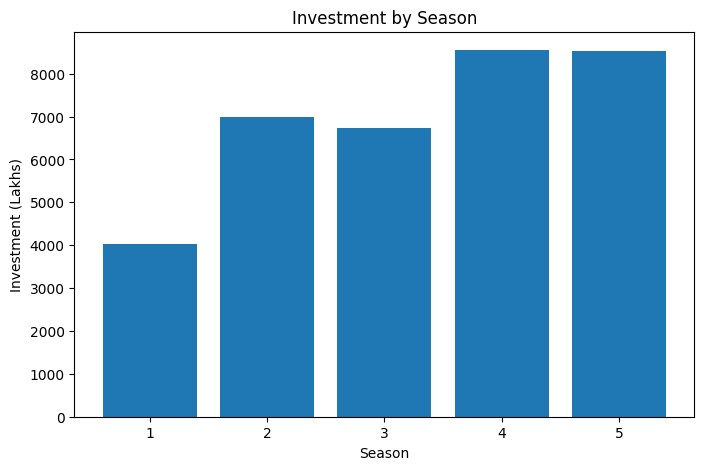

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    season_analysis["season_number"],
    season_analysis["total_investment"]
)

plt.xlabel("Season")
plt.ylabel("Investment (Lakhs)")
plt.title("Investment by Season")

plt.show()

In [37]:
industry_analysis = (
    df.groupby("industry")
    .agg(
        startups=("startup_name", "nunique"),
        total_investment=("total_deal_amount", "sum"),
        total_deals=("deal_count", "sum"),
        average_investment=("total_deal_amount", "mean")
    )
    .reset_index()
    .sort_values(
        "total_investment",
        ascending=False
    )
)

industry_analysis

,industry,startups,total_investment,total_deals,average_investment
2,Beauty/Fashion,158,8256.00000,92,89.739130
8,Food And Beverage,169,7287.60005,96,75.912501
16,Technology/Software,85,4227.00000,49,86.265306
14,Medical/Health,68,4093.00101,47,87.085128
11,Lifestyle/Home,56,1965.00000,24,81.875000
13,Manufacturing,52,1631.00000,26,62.730769
3,Business Services,48,1565.00000,20,78.250000
4,Children/Education,35,1541.00000,20,77.050000
7,Fitness/Sports/Outdoors,28,1205.00000,16,75.312500
9,Green/Cleantech,20,775.01250,9,86.112500


In [38]:
industry_analysis.head(10)

,industry,startups,total_investment,total_deals,average_investment
2,Beauty/Fashion,158,8256.00000,92,89.739130
8,Food And Beverage,169,7287.60005,96,75.912501
16,Technology/Software,85,4227.00000,49,86.265306
14,Medical/Health,68,4093.00101,47,87.085128
11,Lifestyle/Home,56,1965.00000,24,81.875000
13,Manufacturing,52,1631.00000,26,62.730769
3,Business Services,48,1565.00000,20,78.250000
4,Children/Education,35,1541.00000,20,77.050000
7,Fitness/Sports/Outdoors,28,1205.00000,16,75.312500
9,Green/Cleantech,20,775.01250,9,86.112500


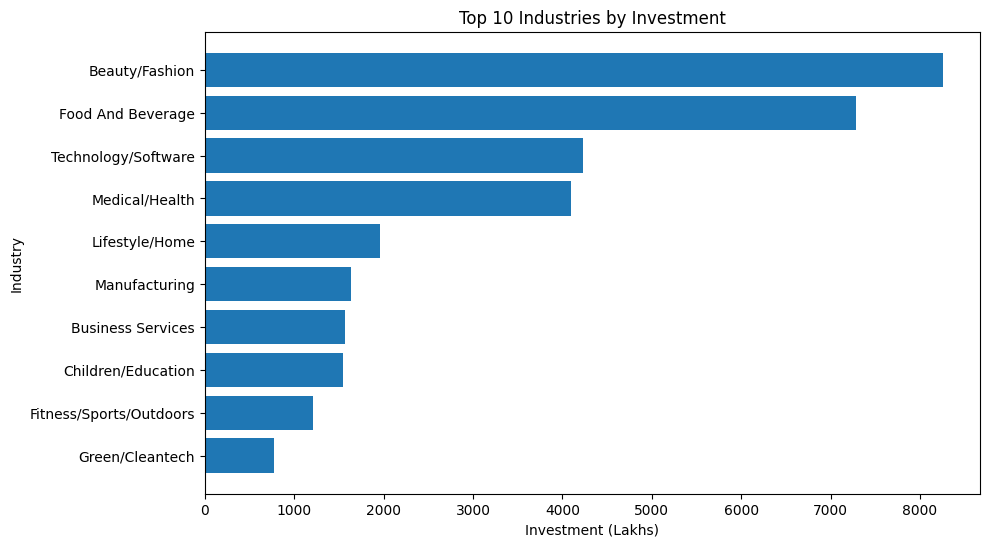

In [39]:
top_industries = industry_analysis.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_industries["industry"],
    top_industries["total_investment"]
)

plt.xlabel("Investment (Lakhs)")
plt.ylabel("Industry")
plt.title("Top 10 Industries by Investment")

plt.gca().invert_yaxis()

plt.show()

In [40]:
top_startups = (
    df[
        [
            "startup_name",
            "industry",
            "total_deal_amount",
            "total_deal_equity"
        ]
    ]
    .dropna(
        subset=["total_deal_amount"]
    )
    .sort_values(
        "total_deal_amount",
        ascending=False
    )
    .head(10)
)

top_startups

,startup_name,industry,total_deal_amount,total_deal_equity
484,NOOE,Technology/Software,500.0,51.00
528,TheNaturikCo,Food And Beverage,400.0,22.22
640,SaveSage,Technology/Software,400.0,9.00
597,Beautywise,Beauty/Fashion,300.0,6.00
482,CultureCircle,Beauty/Fashion,300.0,3.00
646,Emori,Beauty/Fashion,300.0,6.00
365,NasherMiles,Beauty/Fashion,300.0,1.50
634,TheCroffleGuys,Food And Beverage,250.0,5.00
655,TruthAndHair,Beauty/Fashion,250.0,25.00
492,KIWIKisanWindow,Lifestyle/Home,250.0,10.00


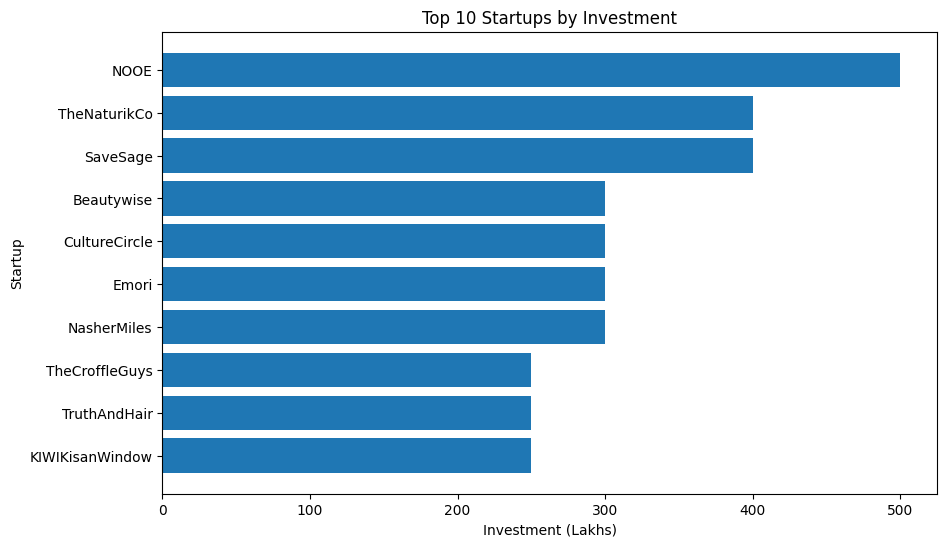

In [41]:
plt.figure(figsize=(10,6))

plt.barh(
    top_startups["startup_name"],
    top_startups["total_deal_amount"]
)

plt.xlabel("Investment (Lakhs)")
plt.ylabel("Startup")
plt.title("Top 10 Startups by Investment")

plt.gca().invert_yaxis()

plt.show()

In [42]:
shark_names = [
    "aman",
    "anupam",
    "ashneer",
    "namita",
    "peyush",
    "vineeta",
    "ghazal",
    "ritesh",
    "amit",
    "guest"
]

shark_columns = []

for col in df.columns:

    for shark in shark_names:

        if shark in col:
            shark_columns.append(col)
            break

print(shark_columns)

['namita_investment_amount', 'namita_investment_equity', 'namita_debt_amount', 'vineeta_investment_amount', 'vineeta_investment_equity', 'vineeta_debt_amount', 'anupam_investment_amount', 'anupam_investment_equity', 'anupam_debt_amount', 'aman_investment_amount', 'aman_investment_equity', 'aman_debt_amount', 'peyush_investment_amount', 'peyush_investment_equity', 'peyush_debt_amount', 'ritesh_investment_amount', 'ritesh_investment_equity', 'ritesh_debt_amount', 'amit_investment_amount', 'amit_investment_equity', 'amit_debt_amount', 'guest_investment_amount', 'guest_investment_equity', 'guest_debt_amount', 'invested_guest_name', 'all_guest_names', 'namita_present', 'vineeta_present', 'anupam_present', 'aman_present', 'peyush_present', 'ritesh_present', 'amit_present', 'guest_present']


In [43]:
df[shark_columns].head()

,namita_investment_amount,namita_investment_equity,namita_debt_amount,vineeta_investment_amount,vineeta_investment_equity,vineeta_debt_amount,anupam_investment_amount,anupam_investment_equity,anupam_debt_amount,aman_investment_amount,...,invested_guest_name,all_guest_names,namita_present,vineeta_present,anupam_present,aman_present,peyush_present,ritesh_present,amit_present,guest_present
0,NaN,NaN,NaN,25.0,5.33,NaN,NaN,NaN,NaN,25.0,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
1,NaN,NaN,NaN,20.0,25.00,NaN,NaN,NaN,NaN,NaN,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
2,NaN,NaN,NaN,12.5,15.00,NaN,12.5,15.0,NaN,NaN,...,<NA>,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,<NA>,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0


In [44]:
investors = {
    "Namita": "namita_investment_amount",
    "Vineeta": "vineeta_investment_amount",
    "Anupam": "anupam_investment_amount",
    "Aman": "aman_investment_amount",
    "Peyush": "peyush_investment_amount",
    "Ritesh": "ritesh_investment_amount",
    "Amit": "amit_investment_amount",
    "Guest": "guest_investment_amount"
}

investor_analysis = []

for investor, column in investors.items():

    total_investment = df[column].fillna(0).sum()

    deals = (df[column].fillna(0) > 0).sum()

    investor_analysis.append({
        "Investor": investor,
        "Total Investment": total_investment,
        "Total Deals": deals
    })

investor_analysis = pd.DataFrame(investor_analysis)

investor_analysis = investor_analysis.sort_values(
    "Total Investment",
    ascending=False
)

investor_analysis

,Investor,Total Investment,Total Deals
3,Aman,7772.883516,163
0,Namita,5427.665268,136
7,Guest,5391.174252,93
2,Anupam,4662.829768,119
4,Peyush,4072.914752,103
1,Vineeta,3420.620500,98
5,Ritesh,2690.150500,59
6,Amit,1384.400000,38


In [45]:
founder_columns = [
    col
    for col in df.columns
    if "founder" in col
    or "presenter" in col
]

print(founder_columns)

['number_of_presenters', 'male_presenters', 'female_presenters', 'transgender_presenters', 'couple_presenters']


In [46]:
if "male_presenters" in df.columns:

    print(
        "Average Male Presenters:",
        round(
            df["male_presenters"].mean(),
            2
        )
    )

if "female_presenters" in df.columns:

    print(
        "Average Female Presenters:",
        round(
            df["female_presenters"].mean(),
            2
        )
    )

Average Male Presenters: 1.59
Average Female Presenters: 0.8


In [49]:
print("Data type:", df["pitchers_average_age"].dtype)

print("\nUnique values:")
print(df["pitchers_average_age"].unique()[:30])

print("\nNon-missing count:")
print(df["pitchers_average_age"].notna().sum())

print("\nMissing count:")
print(df["pitchers_average_age"].isna().sum())

Data type: Float64

Unique values:
<FloatingArray>
[<NA>]
Length: 1, dtype: Float64

Non-missing count:
0

Missing count:
789


In [50]:
average_equity = (
    df["total_deal_equity"]
    .dropna()
    .mean()
)

print(
    "Average Equity:",
    round(average_equity, 2),
    "%"
)

Average Equity: 7.42 %


In [51]:
equity_data = df[
    [
        "startup_name",
        "total_deal_amount",
        "total_deal_equity"
    ]
].dropna()

equity_data.head()

,startup_name,total_deal_amount,total_deal_equity
0,BluePineFoods,75.0,16.00
1,BoozScooters,40.0,50.00
2,HeartUpMySleeves,25.0,30.00
3,TagzFoods,70.0,2.75
7,Peeschute,75.0,6.00


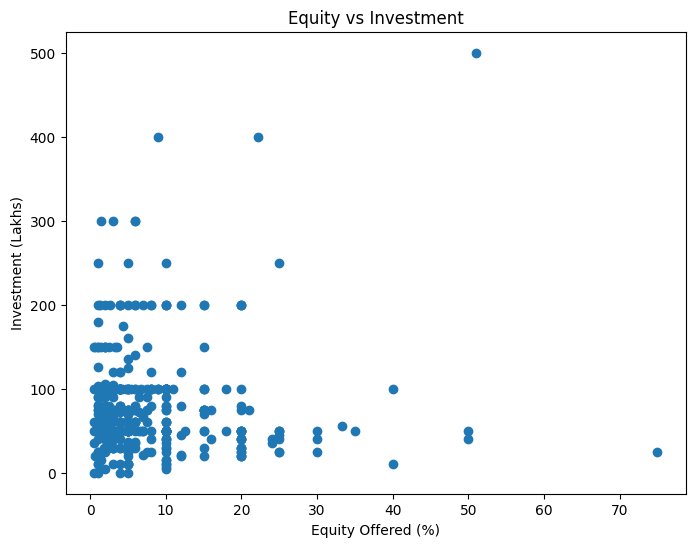

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    equity_data["total_deal_equity"],
    equity_data["total_deal_amount"]
)

plt.xlabel("Equity Offered (%)")
plt.ylabel("Investment (Lakhs)")
plt.title("Equity vs Investment")

plt.show()

In [53]:
df.head()

,season_number,startup_name,episode_number,pitch_number,season_start,season_end,original_air_date,episode_title,anchor,industry,...,vineeta_present,anupam_present,aman_present,peyush_present,ritesh_present,amit_present,guest_present,deal_status,deal_count,investment_in_crores
0,1,BluePineFoods,1,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food And Beverage,...,1.0,1.0,1.0,NaN,NaN,NaN,1.0,Deal,1,0.75
1,1,BoozScooters,1,2,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,...,1.0,1.0,1.0,NaN,NaN,NaN,1.0,Deal,1,0.40
2,1,HeartUpMySleeves,1,3,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,...,1.0,1.0,1.0,NaN,NaN,NaN,1.0,Deal,1,0.25
3,1,TagzFoods,2,4,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food And Beverage,...,1.0,1.0,1.0,NaN,NaN,NaN,1.0,Deal,1,0.70
4,1,HeadAndHeart,2,5,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,...,1.0,1.0,1.0,NaN,NaN,NaN,1.0,No Deal,0,NaN


In [54]:
print(df.shape)

(789, 83)


In [55]:
print(df.columns.tolist())

['season_number', 'startup_name', 'episode_number', 'pitch_number', 'season_start', 'season_end', 'original_air_date', 'episode_title', 'anchor', 'industry', 'business_description', 'company_website', 'started_in', 'number_of_presenters', 'male_presenters', 'female_presenters', 'transgender_presenters', 'couple_presenters', 'pitchers_average_age', 'pitchers_city', 'pitchers_state', 'yearly_revenue', 'monthly_sales', 'gross_margin', 'net_margin', 'ebitda', 'cash_burn', 'skus', 'has_patents', 'bootstrapped', 'part_of_match_off', 'original_ask_amount', 'original_offered_equity', 'valuation_requested', 'received_offer', 'accepted_offer', 'total_deal_amount', 'total_deal_equity', 'total_deal_debt', 'debt_interest', 'deal_valuation', 'number_of_sharks_in_deal', 'deal_has_conditions', 'royalty_percentage', 'royalty_recouped_amount', 'advisory_shares_equity', 'namita_investment_amount', 'namita_investment_equity', 'namita_debt_amount', 'vineeta_investment_amount', 'vineeta_investment_equity', 

In [56]:
output_file = "/content/shark_tank_india_cleaned.csv"

df.to_csv(
    output_file,
    index=False
)

print(
    "Cleaned dataset saved successfully!"
)

print(output_file)

Cleaned dataset saved successfully!
/content/shark_tank_india_cleaned.csv


In [59]:
print("SHARK TANK INDIA - PROJECT SUMMARY")

print("Total Startups:",
      total_startups)

print(
    "Total Investment:",
    round(total_investment_lakhs, 2),
    "Lakhs"
)

print(
    "Total Investment:",
    round(total_investment_crores, 2),
    "Crores"
)

print("Total Deals:",
      total_deals)

print(
    "Deal Success Rate:",
    round(deal_success_rate, 2),
    "%"
)

print(
    "Average Investment:",
    round(average_investment, 2),
    "Lakhs"
)


SHARK TANK INDIA - PROJECT SUMMARY
Total Startups: 789
Total Investment: 34822.91 Lakhs
Total Investment: 348.23 Crores
Total Deals: 433
Deal Success Rate: 54.88 %
Average Investment: 80.24 Lakhs
